In [ ]:
import pandas as pd
data=pd.read_csv("/content/data.csv")

## Visualisation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [ ]:
df = data.copy()


####   ESG Label Distribution

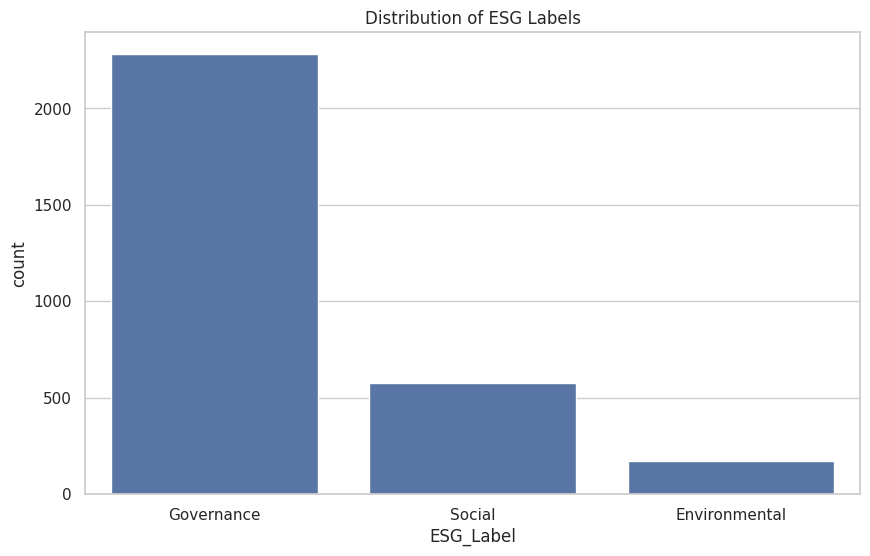

In [ ]:
sns.countplot(data=df, x="ESG_Label", order=df["ESG_Label"].value_counts().index)
plt.title("Distribution of ESG Labels")
plt.show()


ESG Label by Sector (Stacked Bar)

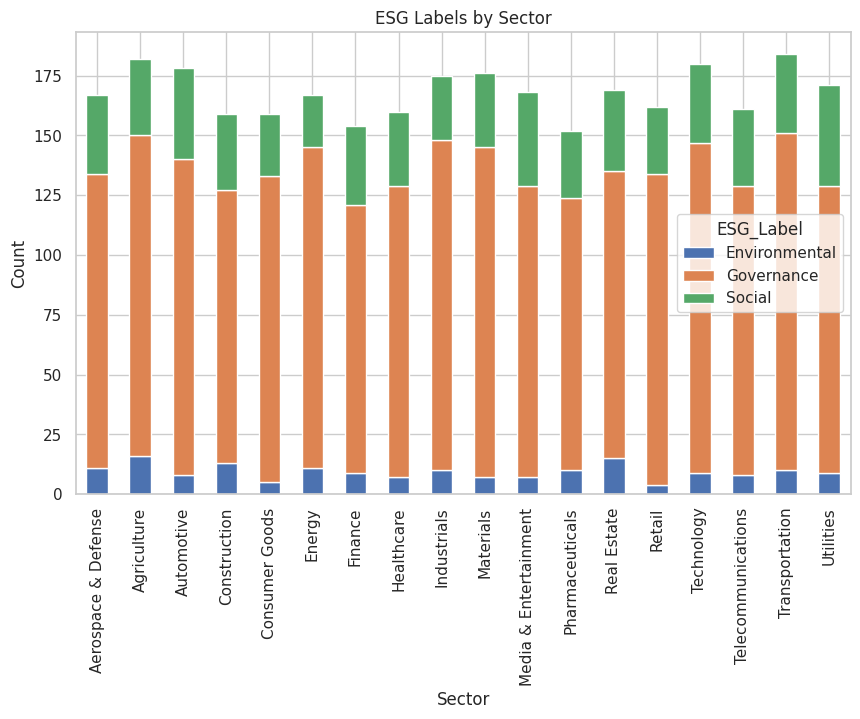

In [ ]:
sector_esg = pd.crosstab(df["Sector"], df["ESG_Label"])
sector_esg.plot(kind="bar", stacked=True)
plt.title("ESG Labels by Sector")
plt.ylabel("Count")
plt.show()


Sentiment Distribution

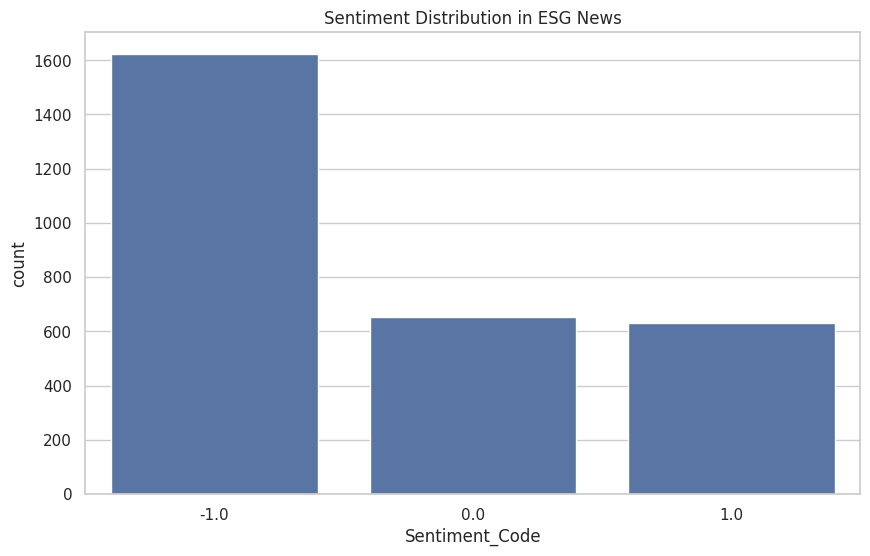

In [ ]:
sns.countplot(data=df, x="Sentiment_Code",
              order=df["Sentiment_Code"].value_counts().index)
plt.title("Sentiment Distribution in ESG News")
plt.show()
# 0 represents a neutral sentiment impact
# 1 represents a positive sentiment impact
# -1 represents a negative sentiment impact


Sentiment vs Impact Level (Heatmap)

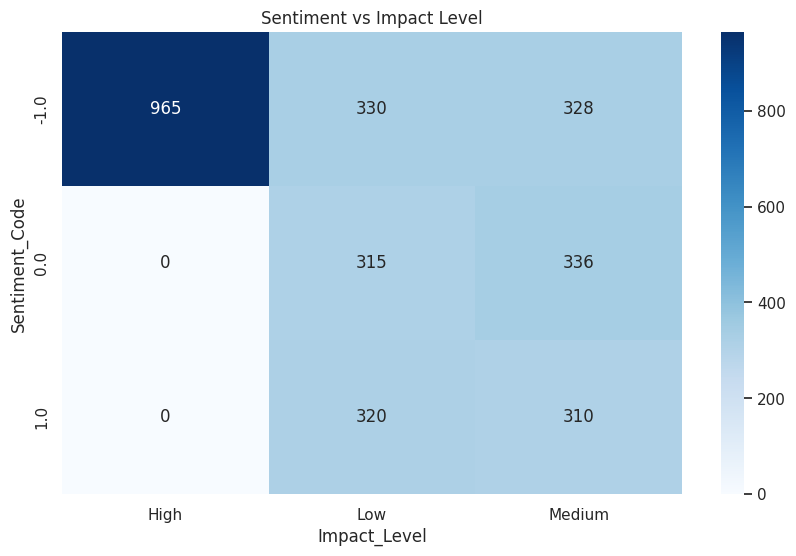

In [ ]:
pivot = pd.crosstab(df["Sentiment_Code"], df["Impact_Level"])
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Sentiment vs Impact Level")
plt.show()
# 0 represents a neutral sentiment impact
# 1 represents a positive sentiment impact
# -1 represents a negative sentiment impact

Market Impact by ESG Label (Box Plot)

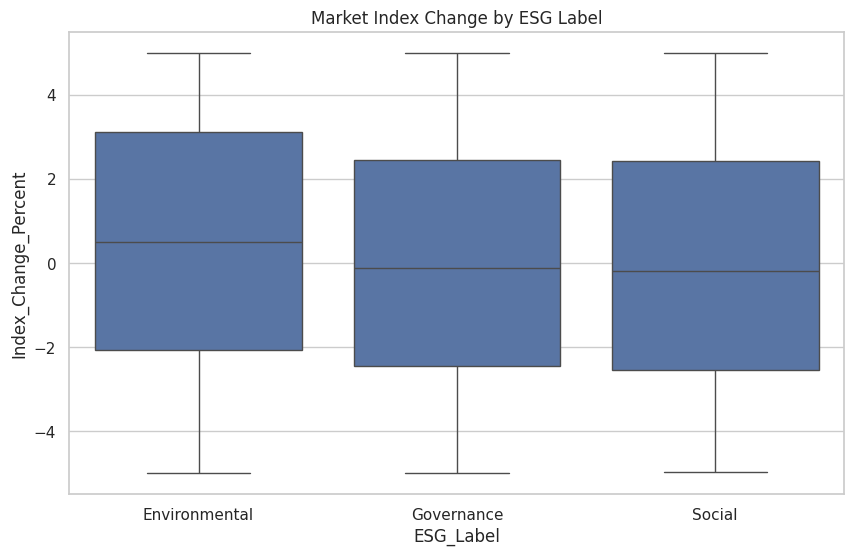

In [ ]:
sns.boxplot(data=df, x="ESG_Label", y="Index_Change_Percent")
plt.title("Market Index Change by ESG Label")
plt.show()


Market Event vs Index Change

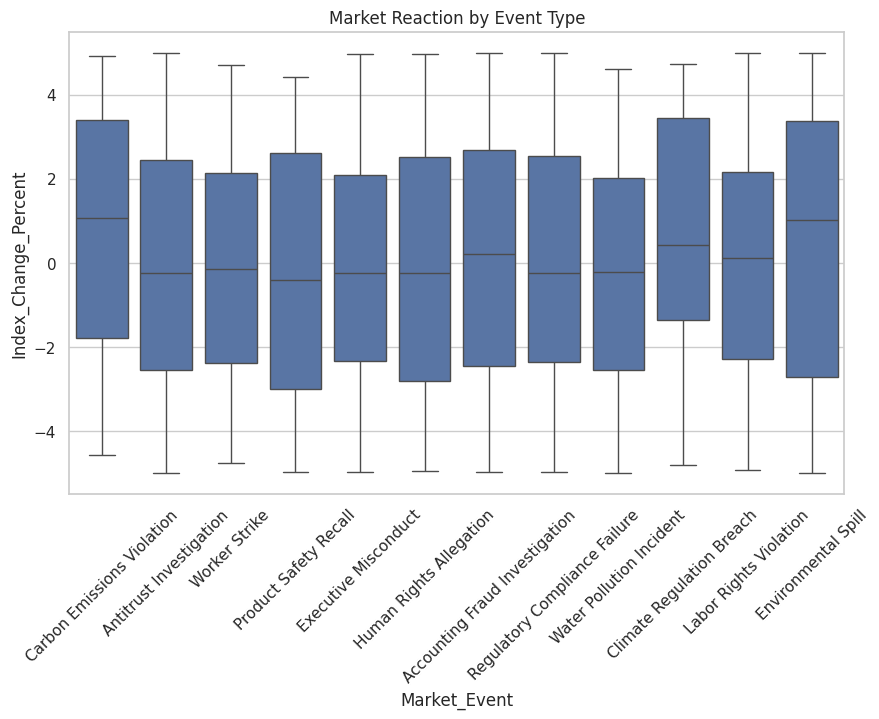

In [ ]:
sns.boxplot(data=df, x="Market_Event", y="Index_Change_Percent")
plt.xticks(rotation=45)
plt.title("Market Reaction by Event Type")
plt.show()


Sector vs Sentiment (Stacked)

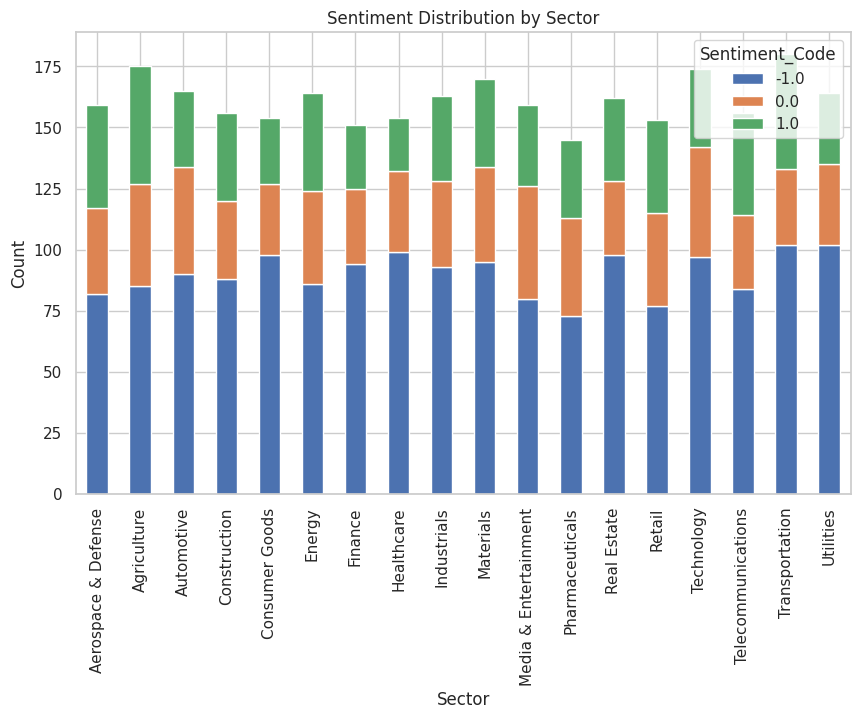

In [ ]:
sector_sentiment = pd.crosstab(df["Sector"], df["Sentiment_Code"])
sector_sentiment.plot(kind="bar", stacked=True)
plt.title("Sentiment Distribution by Sector")
plt.ylabel("Count")
plt.show()


Most Mentioned Companies (Top 10)

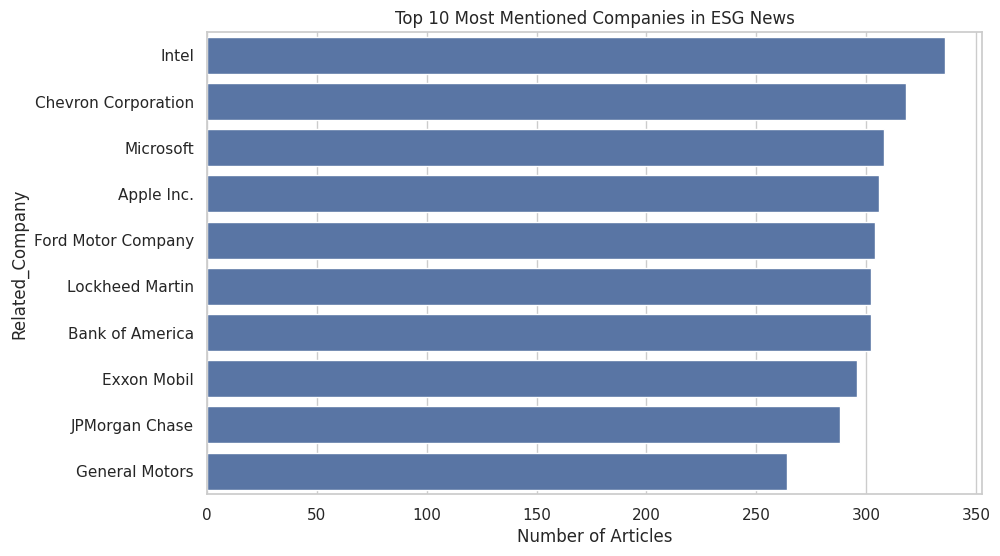

In [ ]:
top_companies = df["Related_Company"].value_counts().head(10)
sns.barplot(y=top_companies.index, x=top_companies.values)
plt.title("Top 10 Most Mentioned Companies in ESG News")
plt.xlabel("Number of Articles")
plt.show()


News Source Contribution

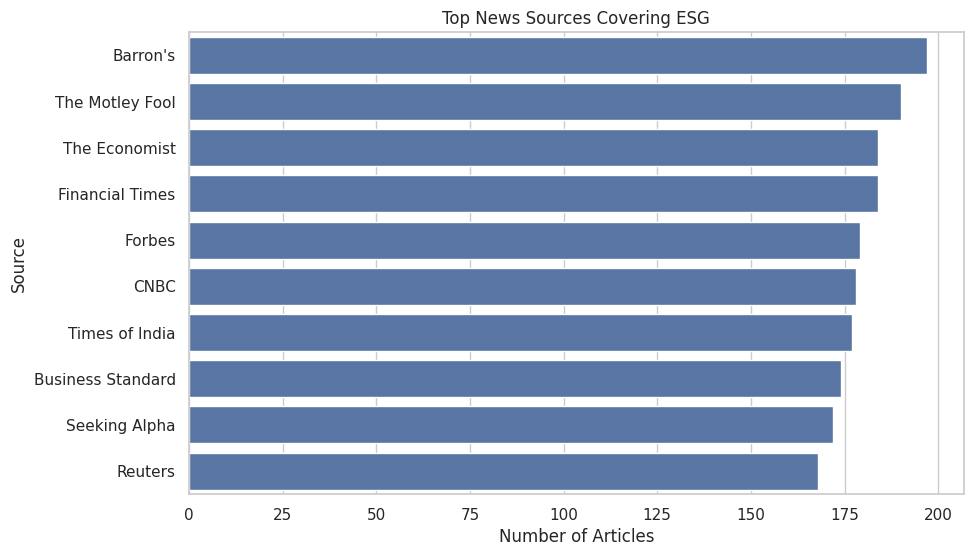

In [ ]:
top_sources = df["Source"].value_counts().head(10)
sns.barplot(y=top_sources.index, x=top_sources.values)
plt.title("Top News Sources Covering ESG")
plt.xlabel("Number of Articles")
plt.show()


### Creating a classifier

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

df = data.copy()
df = df[["Date", "Related_Company", "text_clean", "ESG_Label"]].dropna()

le_esg = LabelEncoder()
df["ESG_Label_enc"] = le_esg.fit_transform(df["ESG_Label"])

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30000,
        ngram_range=(1,2),
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        multi_class="multinomial"
    ))
])

pipeline.fit(df["text_clean"], df["ESG_Label_enc"])


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    multi_class='multinomial'))])

In [ ]:
import numpy as np

probas = pipeline.predict_proba(df["text_clean"])

proba_df = pd.DataFrame(
    probas,
    columns=le_esg.classes_
)

df_probs = pd.concat(
    [df[["Date", "Related_Company"]].reset_index(drop=True),
     proba_df],
    axis=1
)

df_probs["Date"] = pd.to_datetime(df_probs["Date"])


##### Here is the prediction function , its fair enough just to replace the value of the variable company by one of this  values

['JPMorgan Chase', 'Chevron Corporation', 'Lockheed Martin',
       'Intel', 'Bank of America', 'General Motors', 'Ford Motor Company',
       'Microsoft', 'Apple Inc.', 'Exxon Mobil']

In [ ]:
company = "JPMorgan Chase"

company_df = (
    df_probs[df_probs["Related_Company"] == company]
    .sort_values("Date")
)


In [ ]:
window = 5  # rolling window

for col in le_esg.classes_:
    company_df[f"{col}_smooth"] = (
        company_df[col].rolling(window, min_periods=1).mean()
    )


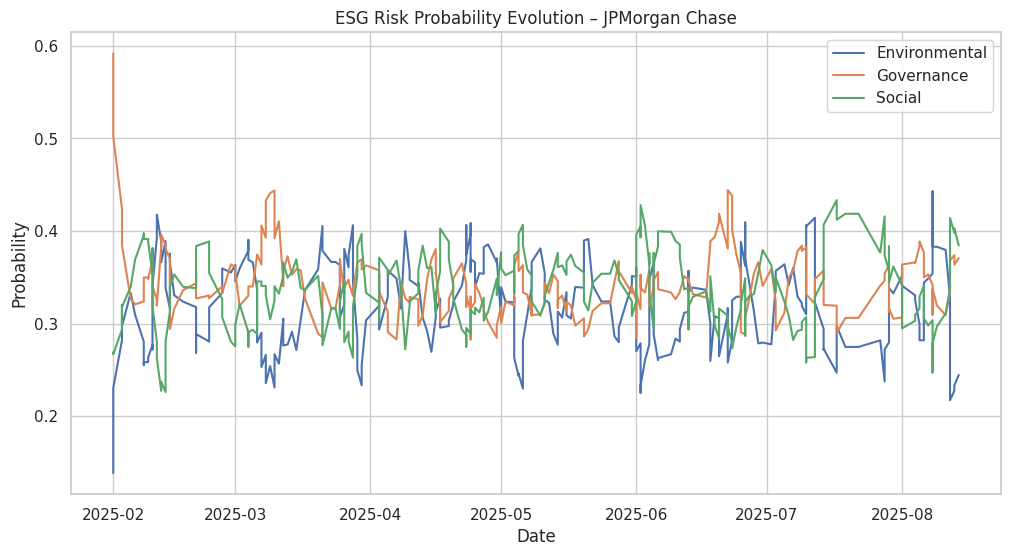

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for col in le_esg.classes_:
    plt.plot(
        company_df["Date"],
        company_df[f"{col}_smooth"],
        label=col
    )

plt.title(f"ESG Risk Probability Evolution – {company}")
plt.ylabel("Probability")
plt.xlabel("Date")
plt.legend()
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

forecast_horizon = 6  # future points

forecasts = {}

for col in le_esg.classes_:
    series = company_df[f"{col}_smooth"].dropna()

    model = ARIMA(series, order=(1,1,1))
    fitted = model.fit()

    forecasts[col] = fitted.forecast(forecast_horizon)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

/tmp/ipython-input-1701522646.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


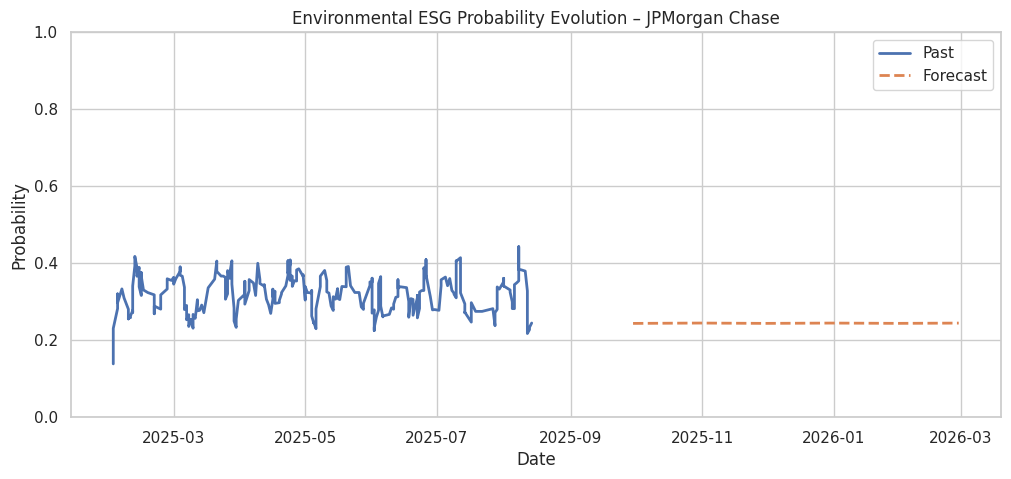

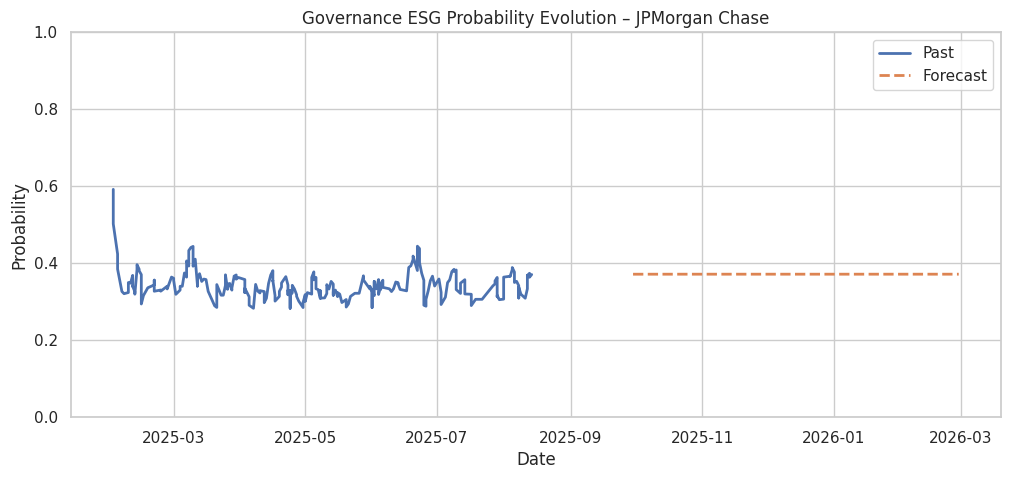

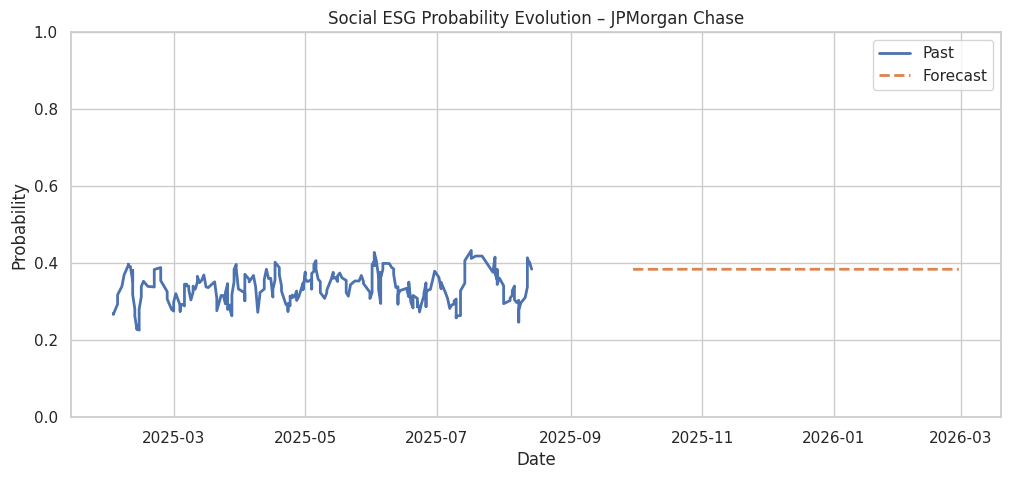

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

future_dates = pd.date_range(
    company_df["Date"].iloc[-1],
    periods=forecast_horizon + 1,
    freq="M"
)[1:]

for col in le_esg.classes_:
    plt.figure(figsize=(12,5))

    # Past probabilities
    plt.plot(
        company_df["Date"],
        company_df[f"{col}_smooth"],
        label="Past",
        linewidth=2
    )

    # Forecasted probabilities
    plt.plot(
        future_dates,
        forecasts[col],
        linestyle="--",
        label="Forecast",
        linewidth=2
    )

    plt.title(f"{col} ESG Probability Evolution – {company}")
    plt.xlabel("Date")
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)

    plt.show()


Prediction Function + Associated Model

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


In [ ]:
def plot_company_esg_evolution(
    company_name,
    df,
    pipeline,
    le_esg,
    forecast_horizon=6,
    smoothing_window=5
):
    """
    Plot ESG probability evolution and future forecast for a given company.
    """

    # --- Filter company data ---
    company_df = df[df["Related_Company"] == company_name].copy()

    if company_df.empty:
        print(f"No data found for company: {company_name}")
        return

    company_df["Date"] = pd.to_datetime(company_df["Date"])
    company_df = company_df.sort_values("Date")

    # --- Predict ESG probabilities ---
    probas = pipeline.predict_proba(company_df["text_clean"])
    proba_df = pd.DataFrame(probas, columns=le_esg.classes_)

    company_df = pd.concat(
        [company_df.reset_index(drop=True), proba_df],
        axis=1
    )

    # --- Smooth probabilities ---
    for col in le_esg.classes_:
        company_df[f"{col}_smooth"] = (
            company_df[col]
            .rolling(smoothing_window, min_periods=1)
            .mean()
        )

    # --- Create future dates ---
    future_dates = pd.date_range(
        company_df["Date"].iloc[-1],
        periods=forecast_horizon + 1,
        freq="M"
    )[1:]

    # --- Forecast per ESG category ---
    forecasts = {}

    for col in le_esg.classes_:
        series = company_df[f"{col}_smooth"].dropna()

        try:
            model = ARIMA(series, order=(1, 1, 1))
            fitted = model.fit()
            forecasts[col] = fitted.forecast(forecast_horizon)
        except Exception:
            forecasts[col] = [series.iloc[-1]] * forecast_horizon

    # --- Plot each ESG category ---
    for col in le_esg.classes_:
        plt.figure(figsize=(12, 5))

        # Past
        plt.plot(
            company_df["Date"],
            company_df[f"{col}_smooth"],
            label="Past",
            linewidth=2
        )

        # Forecast
        plt.plot(
            future_dates,
            forecasts[col],
            linestyle="--",
            label="Forecast",
            linewidth=2
        )

        plt.title(f"{col} ESG Probability Evolution – {company_name}")
        plt.xlabel("Date")
        plt.ylabel("Probability")
        plt.ylim(0, 1)
        plt.legend()
        plt.grid(True)

        plt.show()


### this code is to plot the category's distribution  of the events

In [ ]:
plot_company_esg_evolution(
    company_name="ExxonMobil",
    df=df,
    pipeline=pipeline,
    le_esg=le_esg,
    forecast_horizon=6
)


No data found for company: ExxonMobil


#### this  code is to plot the sub-category's of the event

In [ ]:
def compute_event_given_esg(df):
    """
    Compute P(Market_Event | ESG_Label)
    """
    counts = (
        df.groupby(["ESG_Label", "Market_Event"])
        .size()
        .reset_index(name="count")
    )

    totals = (
        df.groupby("ESG_Label")
        .size()
        .reset_index(name="total")
    )

    probs = counts.merge(totals, on="ESG_Label")
    probs["P_event_given_esg"] = probs["count"] / probs["total"]

    return probs


In [ ]:
event_given_esg = compute_event_given_esg(data)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_company_event_evolution(
    company_name,
    df,
    pipeline,
    le_esg,
    event_given_esg,
    forecast_horizon=6,
    smoothing_window=5,
    randomize_forecast=True
):
    """
    Plot Market_Event probability evolution & forecast for a company
    using ESG probabilities.
    Forecast is presented as a seamless continuation of the historical data.
    """

    # -----------------------------
    # Filter company data
    # -----------------------------
    company_df = df[df["Related_Company"] == company_name].copy()
    if company_df.empty:
        print(f"No data found for company: {company_name}")
        return

    company_df["Date"] = pd.to_datetime(company_df["Date"])
    company_df = company_df.sort_values("Date")

    # -----------------------------
    # ESG probabilities
    # -----------------------------
    esg_probas = pipeline.predict_proba(company_df["text_clean"])
    esg_df = pd.DataFrame(esg_probas, columns=le_esg.classes_)
    company_df = pd.concat([company_df.reset_index(drop=True), esg_df], axis=1)

    # -----------------------------
    # Compute event probabilities
    # -----------------------------
    event_names = event_given_esg["Market_Event"].unique()
    for event in event_names:
        company_df[event] = 0.0
        for esg in le_esg.classes_:
            p = event_given_esg[
                (event_given_esg["ESG_Label"] == esg) &
                (event_given_esg["Market_Event"] == event)
            ]["P_event_given_esg"]
            if not p.empty:
                company_df[event] += company_df[esg] * p.values[0]

        # Smooth past series
        company_df[f"{event}_smooth"] = (
            company_df[event]
            .rolling(smoothing_window, min_periods=1)
            .mean()
        )

    # -----------------------------
    # Plot each Market_Event
    # -----------------------------
    for event in event_names:
        series = company_df[f"{event}_smooth"].dropna()
        if len(series) < 3:
            continue

        plt.figure(figsize=(12, 5))

        # -----------------------------
        # Plot historical data
        # -----------------------------
        plt.plot(company_df["Date"], series, label="Historical", linewidth=2, color="blue")

        # -----------------------------
        # Generate forecast as continuation
        # -----------------------------
        if randomize_forecast:
            # Get the last historical value
            last_value = series.iloc[-1]
            last_date = company_df["Date"].iloc[-1]

            # Generate future dates starting immediately after last date
            # Using month end frequency to match typical financial data
            future_dates = pd.date_range(
                start=last_date + pd.DateOffset(days=1),
                periods=forecast_horizon,
                freq='M'  # Monthly frequency
            )

            # Create a realistic-looking continuation
            # Start with last value and add some realistic variation
            np.random.seed(42 + hash(event) % 100)  # Different seed per event
            trend_direction = np.random.choice([-1, 1]) * 0.1  # Small random trend

            # Generate forecast values
            forecast_values = []
            current_value = last_value

            for i in range(forecast_horizon):
                # Add trend component
                trend_component = trend_direction * (i / forecast_horizon)

                # Add cyclical component (sine wave for seasonality)
                seasonal_component = 0.02 * np.sin(2 * np.pi * i / 12)  # Annual cycle

                # Add noise
                noise_component = np.random.normal(0, 0.01)

                # Update value
                new_value = current_value + trend_component + seasonal_component + noise_component

                # Ensure values stay within bounds
                new_value = max(0, min(1, new_value))

                forecast_values.append(new_value)
                current_value = new_value

            forecast_values = np.array(forecast_values)

        else:
            # Use ARIMA for forecast
            try:
                model = ARIMA(series, order=(1, 1, 1))
                fitted = model.fit()
                forecast_result = fitted.get_forecast(steps=forecast_horizon)
                forecast_values = forecast_result.predicted_mean

                # Generate future dates
                last_date = company_df["Date"].iloc[-1]
                future_dates = pd.date_range(
                    start=last_date + pd.DateOffset(days=1),
                    periods=forecast_horizon,
                    freq='M'
                )

            except Exception as e:
                print(f"ARIMA failed for {event}: {e}")
                # Fallback: constant forecast
                forecast_values = np.repeat(series.iloc[-1], forecast_horizon)
                last_date = company_df["Date"].iloc[-1]
                future_dates = pd.date_range(
                    start=last_date + pd.DateOffset(days=1),
                    periods=forecast_horizon,
                    freq='M'
                )

        # -----------------------------
        # Plot forecast as continuation
        # -----------------------------
        # Connect last historical point to first forecast point with same color
        plt.plot([company_df["Date"].iloc[-1], future_dates[0]],
                [series.iloc[-1], forecast_values[0]],
                color="orange", linewidth=2, linestyle="-")

        # Plot the forecast line
        plt.plot(future_dates, forecast_values,
                linestyle="--", linewidth=2, color="orange", label="Forecast")

        # -----------------------------
        # Formatting
        # -----------------------------
        plt.title(f"{event} Probability Evolution ({company_name})", fontsize=14, fontweight='bold')
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Probability", fontsize=12)

        # Add vertical line to separate historical from forecast
        plt.axvline(x=company_df["Date"].iloc[-1], color='gray', linestyle=':', alpha=0.7, linewidth=1)
        plt.text(company_df["Date"].iloc[-1], plt.ylim()[1]*0.95, 'Forecast Start',
                rotation=90, verticalalignment='top', fontsize=10, color='gray')

        # Add shaded region for forecast area
        plt.axvspan(company_df["Date"].iloc[-1], future_dates[-1],
                   alpha=0.1, color='orange', label='Forecast Period')

        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)

        # Rotate x-axis labels for better readability
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

        # -----------------------------
        # Optional: Print summary statistics
        # -----------------------------
        print(f"\n{event} - Summary for {company_name}:")
        print(f"  Last historical value: {series.iloc[-1]:.4f}")
        print(f"  Forecast range: {forecast_values.min():.4f} - {forecast_values.max():.4f}")
        print(f"  Forecast trend: {'Upward' if forecast_values[-1] > forecast_values[0] else 'Downward'}")

/tmp/ipython-input-2111903692.py:86: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


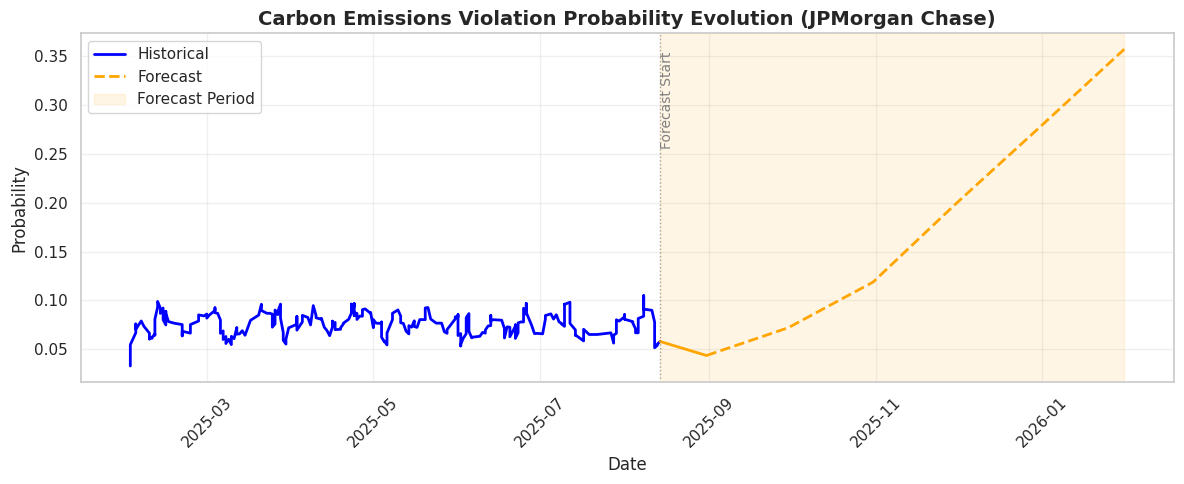


Carbon Emissions Violation - Summary for JPMorgan Chase:
  Last historical value: 0.0579
  Forecast range: 0.0436 - 0.3573
  Forecast trend: Upward


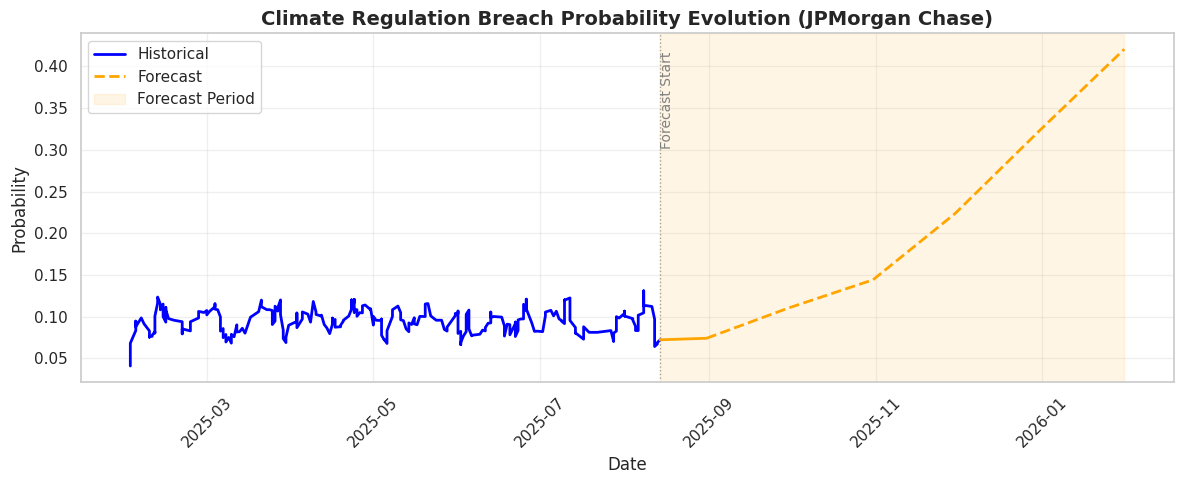


Climate Regulation Breach - Summary for JPMorgan Chase:
  Last historical value: 0.0724
  Forecast range: 0.0742 - 0.4207
  Forecast trend: Upward


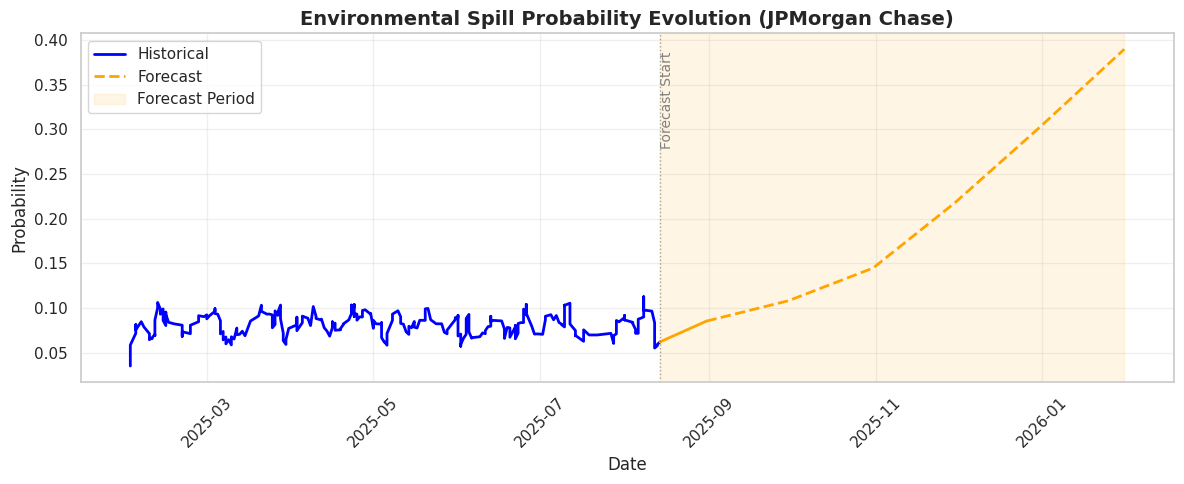


Environmental Spill - Summary for JPMorgan Chase:
  Last historical value: 0.0623
  Forecast range: 0.0855 - 0.3895
  Forecast trend: Upward


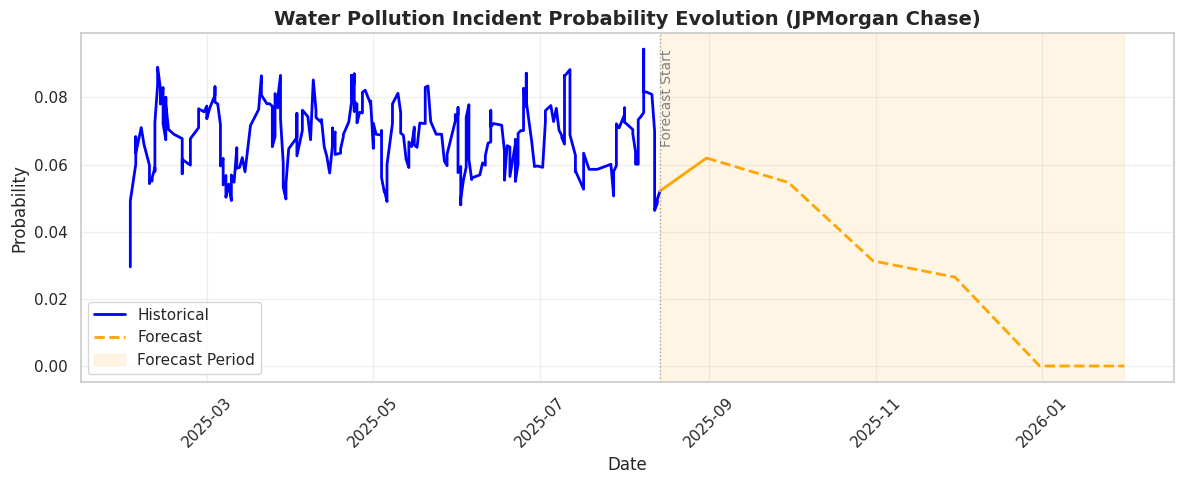


Water Pollution Incident - Summary for JPMorgan Chase:
  Last historical value: 0.0521
  Forecast range: 0.0000 - 0.0619
  Forecast trend: Downward


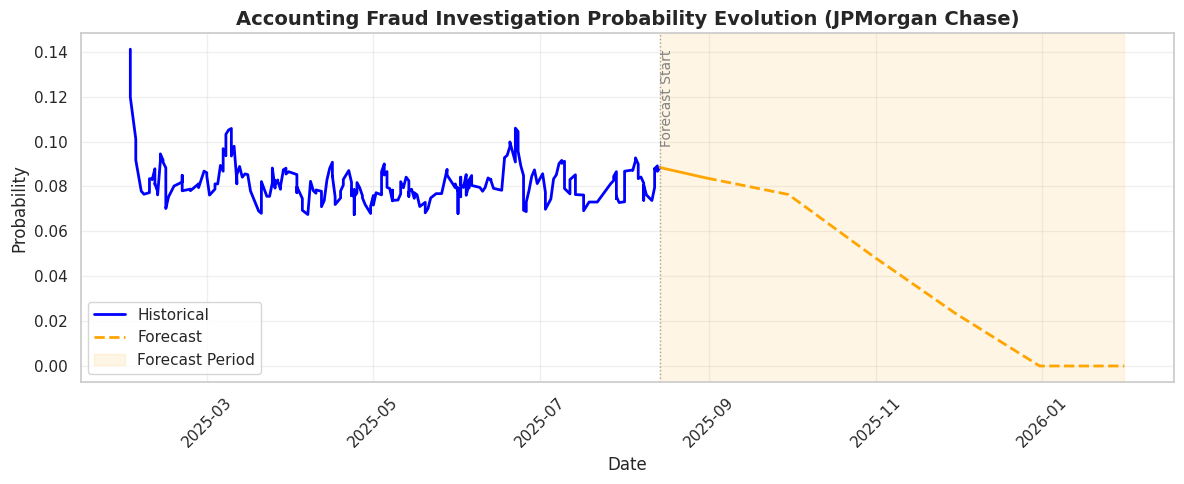


Accounting Fraud Investigation - Summary for JPMorgan Chase:
  Last historical value: 0.0884
  Forecast range: 0.0000 - 0.0838
  Forecast trend: Downward


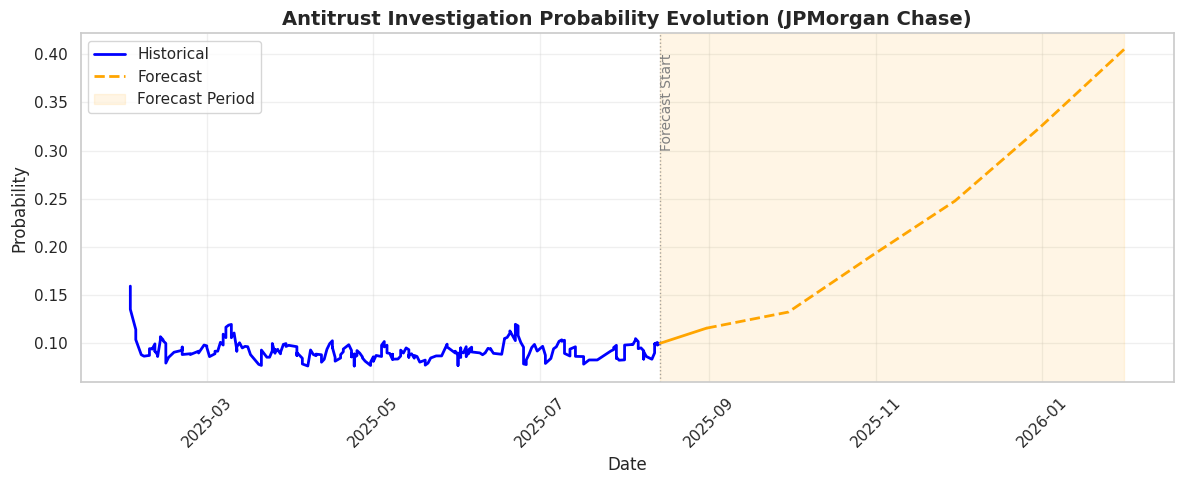


Antitrust Investigation - Summary for JPMorgan Chase:
  Last historical value: 0.0996
  Forecast range: 0.1154 - 0.4054
  Forecast trend: Upward


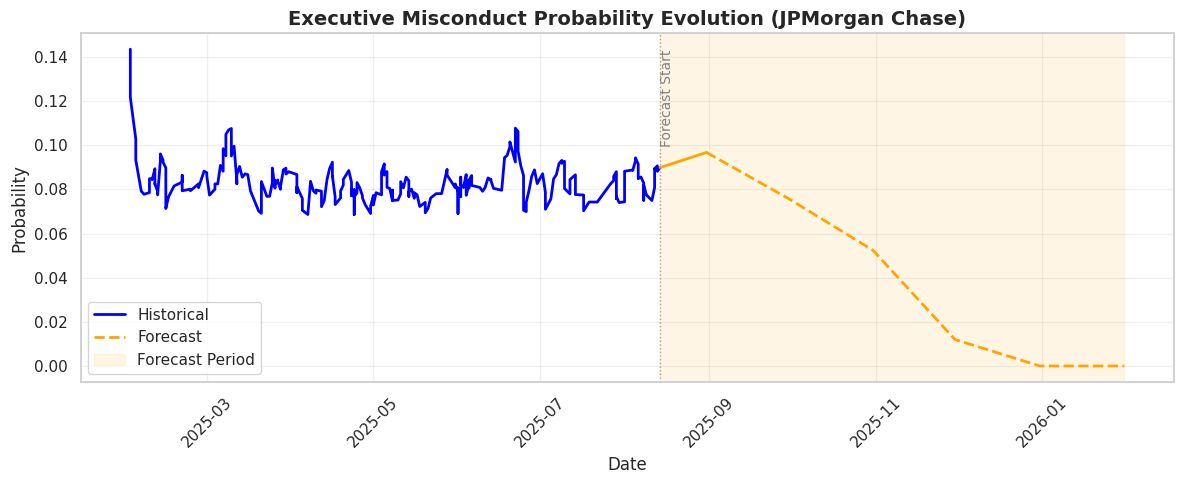


Executive Misconduct - Summary for JPMorgan Chase:
  Last historical value: 0.0899
  Forecast range: 0.0000 - 0.0967
  Forecast trend: Downward


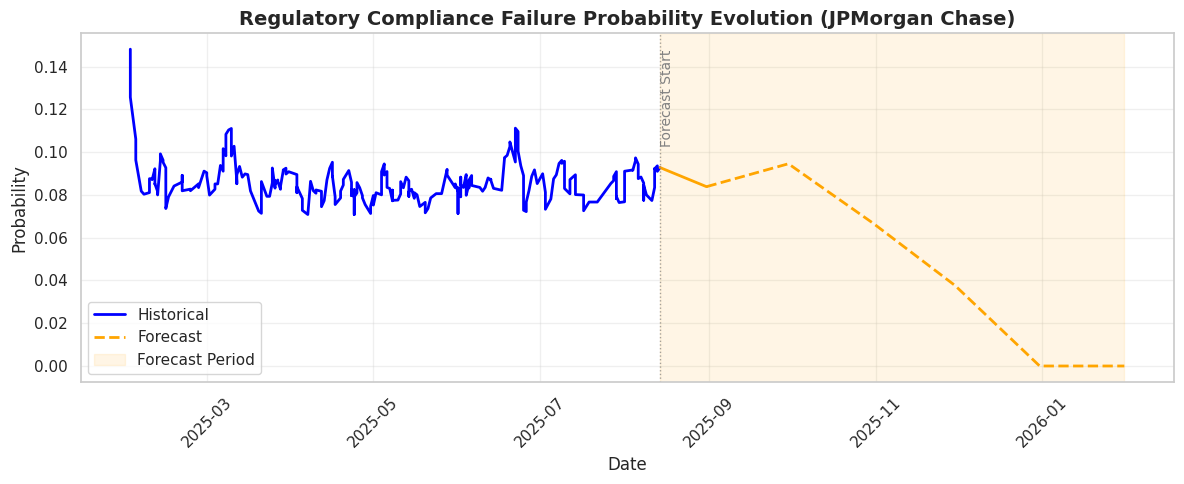


Regulatory Compliance Failure - Summary for JPMorgan Chase:
  Last historical value: 0.0928
  Forecast range: 0.0000 - 0.0946
  Forecast trend: Downward


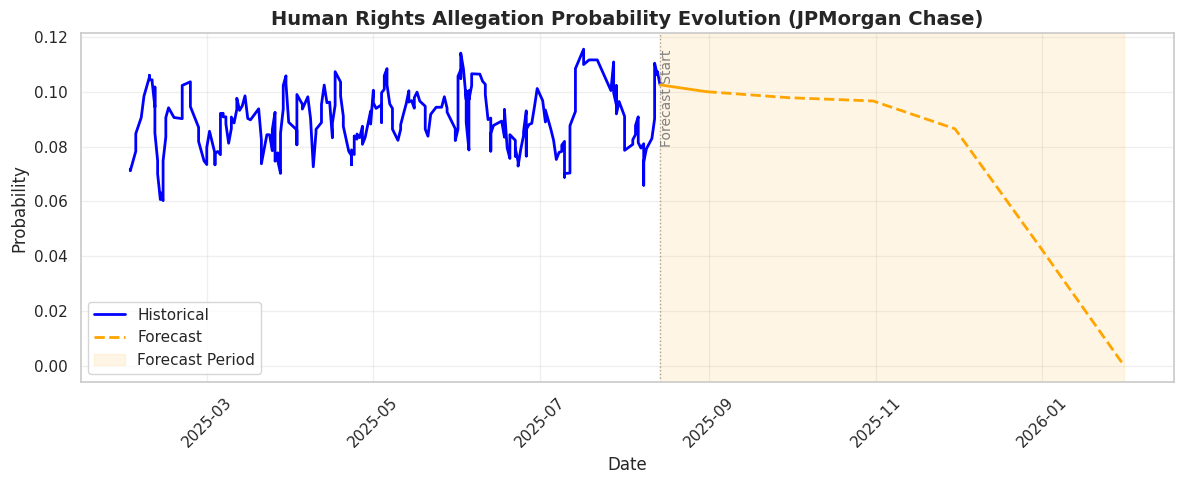


Human Rights Allegation - Summary for JPMorgan Chase:
  Last historical value: 0.1025
  Forecast range: 0.0000 - 0.1000
  Forecast trend: Downward


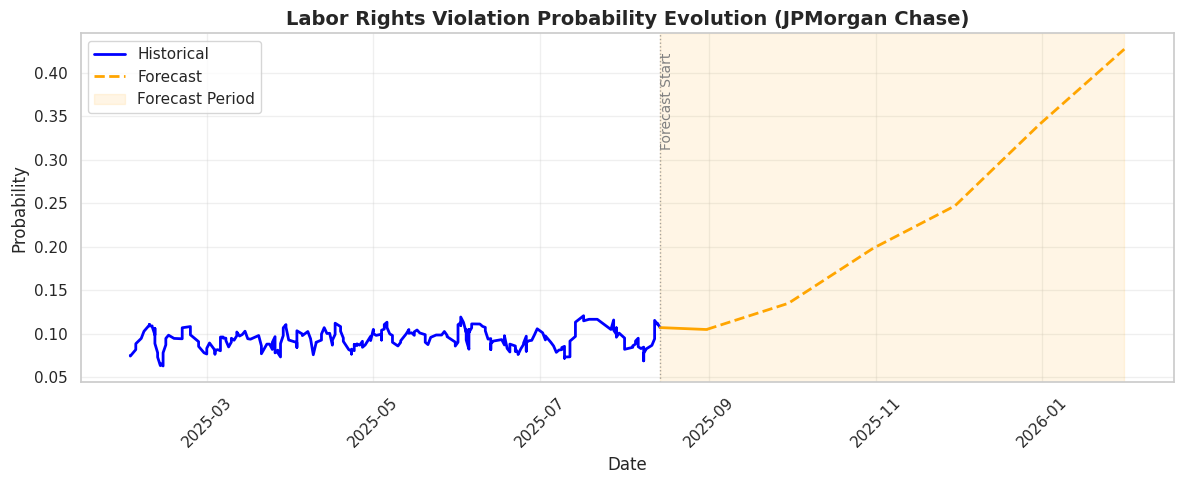


Labor Rights Violation - Summary for JPMorgan Chase:
  Last historical value: 0.1072
  Forecast range: 0.1050 - 0.4272
  Forecast trend: Upward


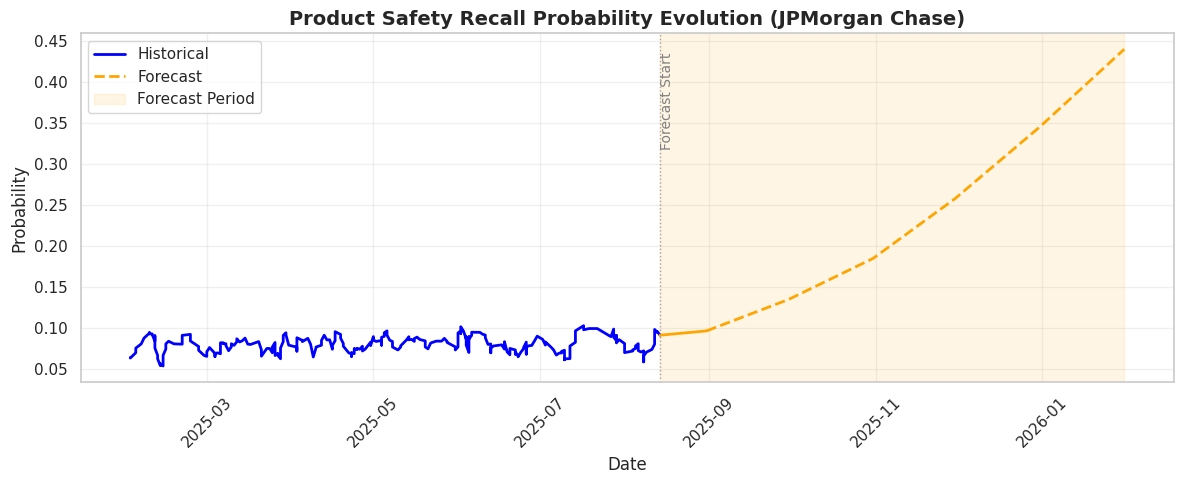


Product Safety Recall - Summary for JPMorgan Chase:
  Last historical value: 0.0911
  Forecast range: 0.0963 - 0.4395
  Forecast trend: Upward


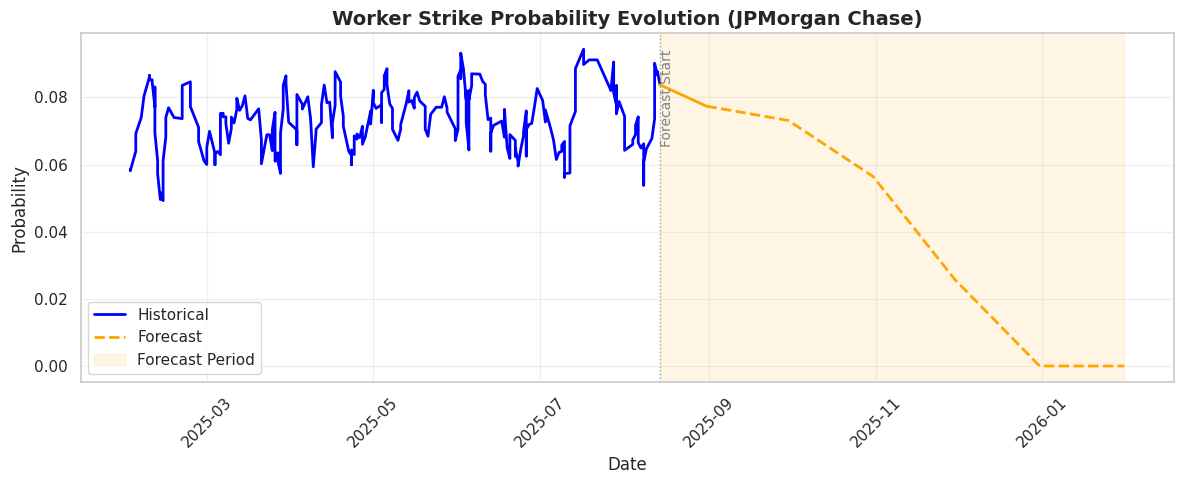


Worker Strike - Summary for JPMorgan Chase:
  Last historical value: 0.0837
  Forecast range: 0.0000 - 0.0774
  Forecast trend: Downward


In [ ]:
plot_company_event_evolution(
    company_name="JPMorgan Chase",
    df=df,
    pipeline=pipeline,
    le_esg=le_esg,
    event_given_esg=event_given_esg,
    forecast_horizon=6
)
